<a href="https://colab.research.google.com/github/pranojit9/AI-In-Healthcare/blob/main/Coding_Assignment_1/python_script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                     Accuracy  Precision    Recall
Logistic Regression  0.973684   0.972222  0.985915
Random Forest        0.964912   0.958904  0.985915
SVM                  0.973684   0.972222  0.985915


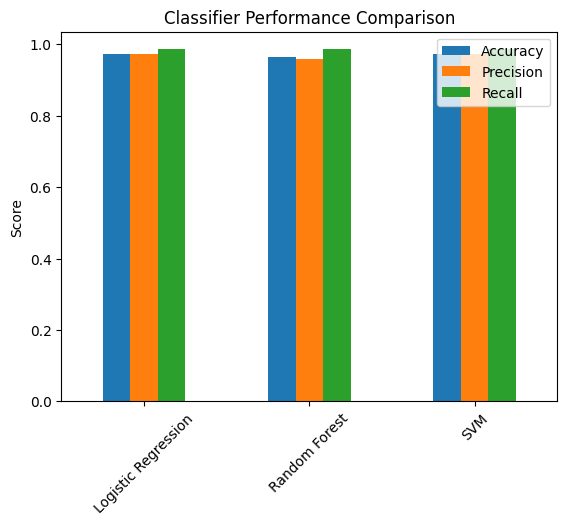

Top Performing Model: Logistic Regression


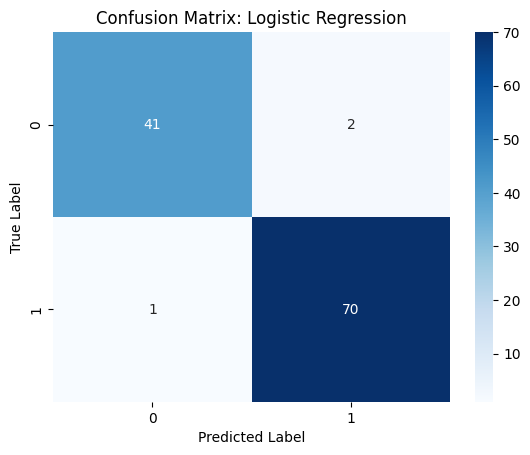

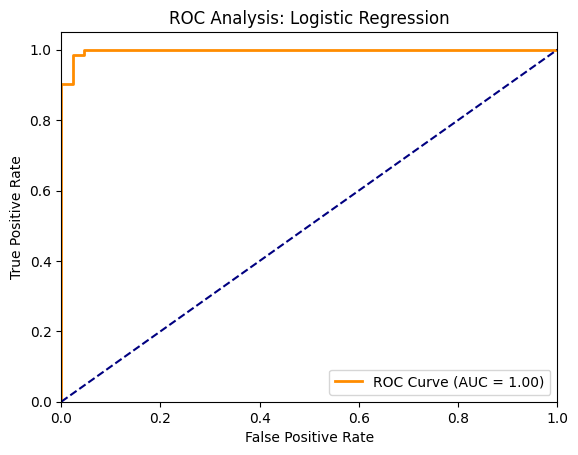

In [4]:
# ML Project: Breast Cancer Diagnostic Classification
# Goal: Comparing multiple classifiers to predict malignancy
# ================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, roc_curve, auc


# 1. Dataset Acquisition and Preparation
# ================================================================
data = load_breast_cancer()

# Constructing DataFrame for easier exploration
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target


# 2. Feature Engineering and Data Splitting
# ================================================================
X = df.drop('target', axis=1)
y = df['target']

# Scaling features to ensure uniform distribution (Crucial for SVM/LogReg)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


# 3. Model Initialization and Training
# ================================================================
# Defining a dictionary of candidate models for comparison
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

results = {}

# Iterating through models to train and capture performance metrics
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred)
    }

# Displaying model performance summary
results_df = pd.DataFrame(results).T
print(results_df)


# 4. Performance Visualization
# ================================================================
# Comparative Bar Chart for metrics
results_df.plot(kind='bar')
plt.title("Classifier Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

# Identifying the top-performing model based on Accuracy
best_model_name = results_df['Accuracy'].idxmax()
best_model = models[best_model_name]

print(f"Top Performing Model: {best_model_name}")


# 5. Advanced Evaluation (Best Model)
# ================================================================

# Plotting Confusion Matrix to analyze True vs False predictions
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Generating ROC Curve and Calculating AUC for diagnostic capability
y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Analysis: {best_model_name}')
plt.legend(loc="lower right")
plt.show()